# **Camera Calibration & Lens Undistortion**

## **Objectives:**
1. Detect a chessboard pattern's corners across many photos of it
2. Solve for the camera matrix and lens distortion coefficients
3. Undistort a new photo taken with the same camera

> **Assets.** `assets/images/calib/left01.jpg` … `left14.jpg` are OpenCV's own official calibration sample photos ([opencv/opencv, Apache 2.0](https://github.com/opencv/opencv/tree/4.x/samples/data)) — 13 photos of the same 9×6 checkerboard, held at different angles and distances in front of one camera. This is the exact dataset OpenCV's own calibration tutorial and C++ `calibration.cpp` sample use. The matching `right01.jpg`…`right14.jpg` set (also bundled here) is used in notebook 32.

## **Why a real photo isn't a perfect grid**

Every real lens bends light slightly — straight lines in the world don't land as perfectly straight lines on the sensor. Two effects dominate:

- **Radial distortion** — light bends more at the edges of the lens than at its center, bowing straight lines outward ("barrel" distortion, the common case for wide lenses) or inward ("pincushion"). Modeled with coefficients `k1, k2, k3` on the point's distance from the image center.
- **Tangential distortion** — the lens isn't perfectly parallel to the sensor, so the image tilts slightly. Modeled with `p1, p2`.

A **chessboard** is the calibration target of choice because its corners are unambiguous, evenly spaced, and easy to detect automatically — `cv2.findChessboardCorners` finds every internal corner, giving a dense set of points whose *true* positions (a perfect grid, `objp` below) are known exactly. Feed enough photos of the same board from *different angles* — different distances, different tilts — and `cv2.calibrateCamera` can solve for the one camera matrix and distortion model that best explains all of them at once. A single photo can't do this: there's no way to tell a lens's distortion apart from the board simply being tilted in that one shot, until you see the *same* board warp differently across several viewpoints.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB) if image.ndim == 3 else image, cmap=None if image.ndim == 3 else 'gray')
    plt.title(title)
    plt.show()

## **Finding corners across the calibration set**

`objp` is the checkerboard's corners in an idealized, flat coordinate system — (0,0), (1,0), (2,0)... — the same for every photo, since it's the same physical board. `cv2.cornerSubPix` refines each detected corner to sub-pixel accuracy afterward; the raw `findChessboardCorners` result is only accurate to the nearest pixel.

`left12.jpg` is deliberately excluded here and kept aside as a genuinely **held-out** test photo for the undistortion step below — calibrating and then "testing" on one of the very photos used to calibrate would quietly flatter the result.

Corners found in 12/12 calibration photos (assets/images/calib/left12.jpg held out for testing)


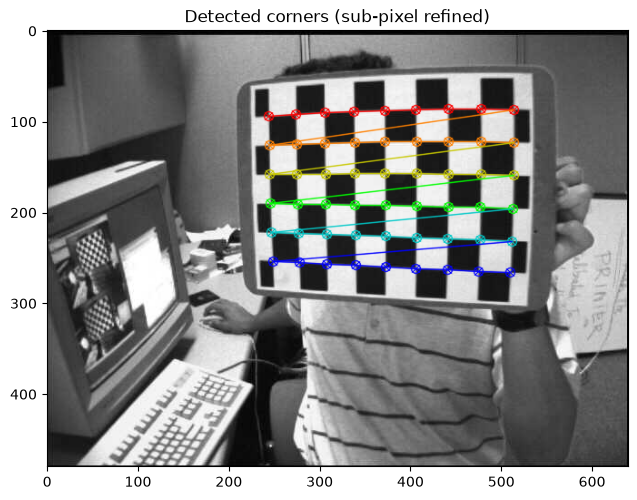

In [2]:
import glob

pattern_size = (9, 6)  # internal corners, not squares
objp = np.zeros((pattern_size[0] * pattern_size[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:pattern_size[0], 0:pattern_size[1]].T.reshape(-1, 2)

HELD_OUT = 'assets/images/calib/left12.jpg'
calibration_paths = sorted(
    p for p in glob.glob('assets/images/calib/left*.jpg') if p != HELD_OUT
)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
objpoints, imgpoints = [], []
img_shape = None
found_vis = None

for path in calibration_paths:
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_shape = gray.shape[::-1]
    found, corners = cv2.findChessboardCorners(gray, pattern_size, None)
    if found:
        corners = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
        objpoints.append(objp)
        imgpoints.append(corners)
        if found_vis is None:
            found_vis = cv2.drawChessboardCorners(img.copy(), pattern_size, corners, found)

print(f'Corners found in {len(objpoints)}/{len(calibration_paths)} calibration photos '
      f'({HELD_OUT} held out for testing)')
imshow('Detected corners (sub-pixel refined)', found_vis)

## **Solving for the camera matrix**

`cv2.calibrateCamera` returns the **RMS reprojection error** — take every detected corner, project it back through the solved camera model, and measure how far off it lands from where it was actually detected, averaged over every corner in every photo. Under ~0.5 pixels is a good, trustworthy calibration; the camera matrix's `fx, fy` (focal length in pixel units) and `cx, cy` (principal point — rarely exactly the image center) are what every later undistort/reproject call relies on.

In [3]:
ret, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
    objpoints, imgpoints, img_shape, None, None,
)

print(f'RMS reprojection error: {ret:.4f} pixels')
print('Camera matrix:\n', camera_matrix)
print('Distortion coefficients (k1, k2, p1, p2, k3):', dist_coeffs.ravel())

RMS reprojection error: 0.4212 pixels
Camera matrix:
 [[536.20720307   0.         341.97586751]
 [  0.         536.17972029 235.77399482]
 [  0.           0.           1.        ]]
Distortion coefficients (k1, k2, p1, p2, k3): [-0.26638737 -0.01846952  0.00190123 -0.00054446  0.1838161 ]


## **Undistorting a held-out photo**

`left12.jpg` was held out of calibration entirely, so this is a genuine test, not calibration data checking itself. `cv2.getOptimalNewCameraMatrix(..., alpha=1)` keeps *every* pixel from the original image — nothing gets cropped away — but since undistorting a rectangle can't produce another perfect rectangle, the corners where no source pixel maps to have to be filled with black. **That curved black border is easy to misread as "still distorted"** — it's actually the opposite: it's proof the remapping is warping the frame *outward* to straighten the content inside it. `roi` tells you exactly which sub-rectangle is real (no black), which the next cell crops to for an honest, black-border-free side-by-side.

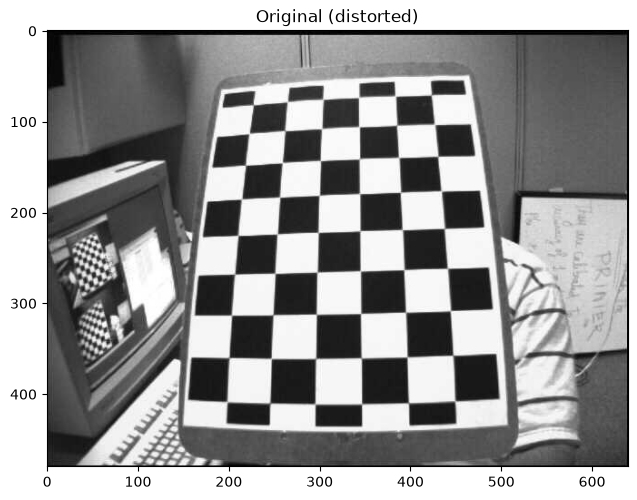

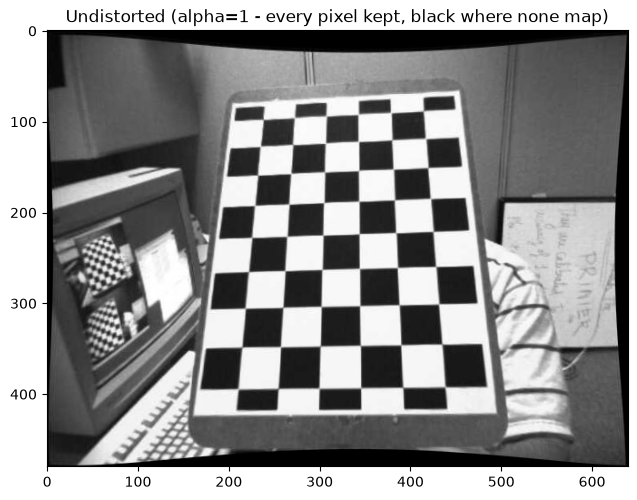

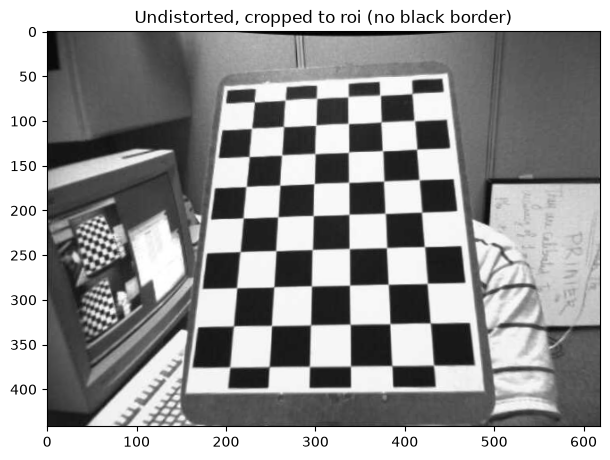

In [4]:
test_img = cv2.imread(HELD_OUT)
h, w = test_img.shape[:2]
new_camera_matrix, roi = cv2.getOptimalNewCameraMatrix(
    camera_matrix, dist_coeffs, (w, h), 1, (w, h),
)
undistorted = cv2.undistort(test_img, camera_matrix, dist_coeffs, None, new_camera_matrix)

imshow('Original (distorted)', test_img)
imshow('Undistorted (alpha=1 - every pixel kept, black where none map)', undistorted)

rx, ry, rw, rh = roi
imshow('Undistorted, cropped to roi (no black border)', undistorted[ry:ry+rh, rx:rx+rw])

## **Proving it, not just eyeballing it**

A curved black border next to a checkerboard is genuinely hard to judge by eye — so measure it instead. Each row of the checkerboard's own internal corners should be a perfectly straight line; fit a line to each row and measure how far the actual detected corners deviate from it, in both the original and the undistorted photo.

In [5]:
def row_straightness(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    found, corners = cv2.findChessboardCorners(gray, pattern_size, None)
    if not found:
        return None
    corners = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria).reshape(-1, 2)
    grid = corners.reshape(pattern_size[1], pattern_size[0], 2)  # rows x cols x (x,y)
    deviations = []
    for row in grid:
        px, py = row[:, 0], row[:, 1]
        m, b = np.polyfit(px, py, 1)  # best-fit straight line through this row
        deviations.append(np.abs(py - (m * px + b)))
    return np.concatenate(deviations)

dev_before = row_straightness(test_img)
dev_after = row_straightness(undistorted)
print(f'Original:    mean {dev_before.mean():.2f}px, max {dev_before.max():.2f}px deviation from straight')
print(f'Undistorted: mean {dev_after.mean():.2f}px, max {dev_after.max():.2f}px deviation from straight')

Original:    mean 12.86px, max 35.43px deviation from straight
Undistorted: mean 2.96px, max 16.36px deviation from straight


### Small experiments worth running

- Recompute the calibration using only 3 photos instead of 12 — watch the RMS reprojection error get noticeably worse, which is the concrete answer to "how many calibration photos do I actually need?"
- Undistort `assets/images/calib/right01.jpg` too — notice it needs its *own* calibration (a different lens/sensor than the left camera), which is exactly the setup notebook 32's stereo pair needs to be rectified before disparity matching works well.
- Plot each photo's RMS per-view reprojection error (`cv2.calibrateCameraExtended` returns `perViewErrors`) as a bar chart — usually one or two blurry/angled shots dominate the total error.